# Task 0: Tensor Warmup

### Problem 1 — Masked mean
Given x of shape (B, T, C) and y of shape (B, T), compute the mean of x across the T dimension, but only at positions where y == 1. Output shape: (B, C). No Python loops over batch or time. Use broadcasting and masking.

In [1]:
import torch

torch.manual_seed(42)
B, T, C = 2, 4, 3
x = torch.randn(B, T, C)
y = torch.randint(0, 2, (B, T)) # random 0s and 1s

print("x shape:", x.shape)
print("y:\n", y)

# 1. Expand mask to shape (B, T, 1) to broadcast with x over C
mask = (y == 1).unsqueeze(-1)

# 2. Apply mask
x_masked = x * mask

# 3. Sum across T (dim=1)
sum_x = x_masked.sum(dim=1)

# 4. Count valid entries across T (dim=1)
counts = mask.sum(dim=1).clamp(min=1) # avoid division by zero

# 5. Calculate masked mean
masked_mean = sum_x / counts

print("Masked Mean shape:", masked_mean.shape)
print("Masked Mean:\n", masked_mean)


x shape: torch.Size([2, 4, 3])
y:
 tensor([[0, 0, 1, 1],
        [1, 1, 1, 0]])
Masked Mean shape: torch.Size([2, 3])
Masked Mean:
 tensor([[-0.3648, -1.0490,  0.2987],
        [-0.1748, -0.2799, -1.1015]])


### Problem 2 — Softmax from scratch
Implement softmax using only exp, sum, and arithmetic. Verify it matches torch.softmax to 1e-6. Then explain in writing: why is naive softmax numerically unstable, and what is the standard trick to fix it?

In [2]:
def softmax_from_scratch(logits, dim=-1):
    # Log-sum-exp trick: subtract max for numerical stability
    max_logits = logits.max(dim=dim, keepdim=True).values
    shifted_logits = logits - max_logits
    
    # Exponentiate
    exp_logits = torch.exp(shifted_logits)
    
    # Normalize
    sum_exp = exp_logits.sum(dim=dim, keepdim=True)
    return exp_logits / sum_exp

logits = torch.randn(2, 5) * 10 # Some large values
scratch_out = softmax_from_scratch(logits)
torch_out = torch.softmax(logits, dim=-1)

# Verify
diff = (scratch_out - torch_out).abs().max().item()
print("Max difference:", diff)
assert diff < 1e-6, "Does not match torch.softmax!"

print("\nExplanation:")
print("Naive softmax computes exp(x_i) / sum(exp(x_j)). If x_i is large (e.g., 1000), exp(1000) overflows to infinity, leading to NaN outputs. The standard trick is to subtract the maximum value of the logits before exponentiating (log-sum-exp trick). This shifts the largest logit to 0, making the largest exponent exp(0) = 1, completely avoiding overflow. Mathematically, the constant cancels out in the numerator and denominator.")


Max difference: 0.0

Explanation:
Naive softmax computes exp(x_i) / sum(exp(x_j)). If x_i is large (e.g., 1000), exp(1000) overflows to infinity, leading to NaN outputs. The standard trick is to subtract the maximum value of the logits before exponentiating (log-sum-exp trick). This shifts the largest logit to 0, making the largest exponent exp(0) = 1, completely avoiding overflow. Mathematically, the constant cancels out in the numerator and denominator.


### Problem 3 — Attention scores two ways
Given Q and K of shape (B, T, d), compute the attention scores matrix (B, T, T) two ways: once with torch.einsum and once with @ (matmul) plus transpose. Verify they are exactly equal.

In [3]:
B, T, d = 2, 4, 8
Q = torch.randn(B, T, d)
K = torch.randn(B, T, d)

# Way 1: Matmul and Transpose
# Q is (B, T, d)
# K^T needs to be (B, d, T), so we transpose the last two dimensions (-2, -1)
scores_matmul = Q @ K.transpose(-2, -1)

# Way 2: Einsum
# b: batch, t: query time, s: key time, d: feature dimension
scores_einsum = torch.einsum('btd,bsd->bts', Q, K)

# Verify
diff = (scores_matmul - scores_einsum).abs().max().item()
print("Max difference:", diff)
assert diff < 1e-6, "Attention scores do not match!"
print("Both methods produce exactly the same attention scores.")


Max difference: 0.0
Both methods produce exactly the same attention scores.


### Problem 4 — Causal mask
Build a causal mask of shape (T, T) that is 0 on and below the diagonal and -inf above. Apply it (by addition) to an attention score matrix before softmax. Visualize the resulting post-softmax attention matrix for T=8 as a heatmap.

Causal Mask:
 tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


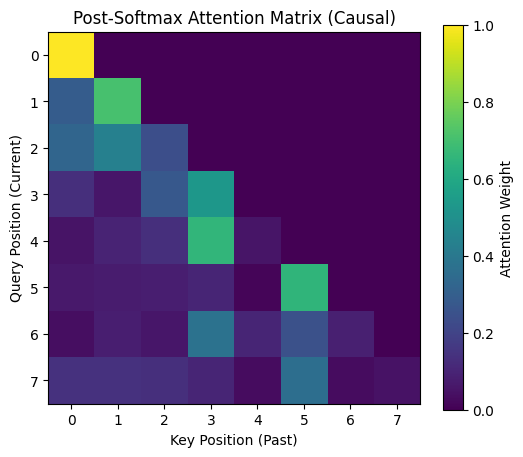

In [4]:
import matplotlib.pyplot as plt

T = 8
# Create causal mask
# torch.tril returns lower triangular part (1s below/on diagonal, 0s above)
tril = torch.tril(torch.ones(T, T))
causal_mask = torch.zeros(T, T).masked_fill(tril == 0, float('-inf'))

print("Causal Mask:\n", causal_mask)

# Simulate random attention scores
scores = torch.randn(T, T)

# Apply mask
masked_scores = scores + causal_mask

# Apply softmax
attention_weights = torch.softmax(masked_scores, dim=-1)

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(attention_weights.numpy(), cmap='viridis')
plt.colorbar(label='Attention Weight')
plt.title('Post-Softmax Attention Matrix (Causal)')
plt.xlabel('Key Position (Past)')
plt.ylabel('Query Position (Current)')
plt.show()


### Problem 5 — LayerNorm from scratch
Given x of shape (B, T, C), implement LayerNorm: compute the mean and variance over the C dimension only (per-token, per-batch), normalize, then apply a learnable scale γ and shift β. Match nn.LayerNorm output to 1e-5.

In [5]:
import torch.nn as nn

def layernorm_from_scratch(x, gamma, beta, eps=1e-5):
    # Mean and variance over the last dimension (C)
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) # PyTorch LayerNorm uses biased variance
    
    # Normalize
    x_norm = (x - mean) / torch.sqrt(var + eps)
    
    # Scale and shift
    return gamma * x_norm + beta

B, T, C = 2, 4, 8
x = torch.randn(B, T, C)

# PyTorch LayerNorm
ln = nn.LayerNorm(C)
torch_out = ln(x)

# Scratch LayerNorm
gamma = ln.weight.detach()
beta = ln.bias.detach()
scratch_out = layernorm_from_scratch(x, gamma, beta)

diff = (scratch_out - torch_out).abs().max().item()
print("Max difference:", diff)
assert diff < 1e-5, "LayerNorm does not match!"
print("LayerNorm from scratch successfully matched nn.LayerNorm")


Max difference: 2.384185791015625e-07
LayerNorm from scratch successfully matched nn.LayerNorm


### Problem 6 — Manual gradients
Take x = torch.randn(4, requires_grad=True). Compute y = (x**2).sum(), call y.backward(), and manually compute on paper what x.grad should be. Verify. Then repeat for y = torch.softmax(x, dim=0).sum() and explain why the gradient looks the way it does (hint: derivative of softmax has a specific structure).

In [6]:
# Part 1: Quadratic
x = torch.randn(4, requires_grad=True)
y = (x**2).sum()
y.backward()

# Manual computation: y = sum(x_i^2). dy/dx_i = 2 * x_i
manual_grad = 2 * x

print("x:", x.detach())
print("Autograd grad:", x.grad)
print("Manual grad:  ", manual_grad.detach())
assert torch.allclose(x.grad, manual_grad), "Quadratic gradients do not match!"

# Part 2: Softmax sum
x2 = torch.randn(4, requires_grad=True)
y2 = torch.softmax(x2, dim=0).sum()
y2.backward()

print("\nx2:", x2.detach())
print("Autograd grad (softmax sum):", x2.grad)

print("\nExplanation:")
print("Let p = softmax(x). We computed y = sum_j(p_j).")
print("By definition, the sum of a softmax distribution over all elements is exactly 1.")
print("Since y = 1 for any input x, y is a constant function.")
print("The derivative of a constant is 0. Therefore, the gradient of sum(softmax(x)) is a vector of all zeros.")
print("Mathematically: dy/dx_i = sum_j (dp_j / dx_i) = sum_j (p_i * (δ_ij - p_j)) = p_i - p_i * sum_j(p_j) = p_i - p_i * 1 = 0.")


x: tensor([-0.7723,  0.1532,  1.3270, -0.8024])
Autograd grad: tensor([-1.5447,  0.3063,  2.6539, -1.6048])
Manual grad:   tensor([-1.5447,  0.3063,  2.6539, -1.6048])

x2: tensor([ 2.9246, -0.7985, -0.5669, -0.0267])
Autograd grad (softmax sum): tensor([0., 0., 0., 0.])

Explanation:
Let p = softmax(x). We computed y = sum_j(p_j).
By definition, the sum of a softmax distribution over all elements is exactly 1.
Since y = 1 for any input x, y is a constant function.
The derivative of a constant is 0. Therefore, the gradient of sum(softmax(x)) is a vector of all zeros.
Mathematically: dy/dx_i = sum_j (dp_j / dx_i) = sum_j (p_i * (δ_ij - p_j)) = p_i - p_i * sum_j(p_j) = p_i - p_i * 1 = 0.
